<a href="https://colab.research.google.com/github/Fr4nckX/Modelo-Predictivo-de-Riesgo-de-Morosidad-en-Clientes-Peruanos-Usando-Aprendizaje-Supervisado/blob/main/notebook/modelo_morosidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Modelo de Clasificación para la Predicción de Riesgo Crediticio
## Sistema Financiero Peruano — BankDefaultAnalysis
---
**Universidad Privada Antenor Orrego**  
**Facultad de Ingeniería — Ingeniería de Sistemas e Inteligencia Artificial**  
**Curso:** Aprendizaje Estadístico  
**Dataset:** BankDefaultAnalysis (Kaggle)  
**Autores:** [Franck Williams Rodriguez Correa]
**Año:** 2026


##  1. Instalación de Librerías y Configuración

In [ ]:
# Instalación de librerías necesarias
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from imblearn.over_sampling import SMOTE

import joblib

print(" Librerías cargadas correctamente")


 Librerías cargadas correctamente


##  2. Carga del Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f" Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(10)


Saving data.csv to data.csv
 Dataset cargado: 8399 filas × 14 columnas


,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ
0,0,235,FAMILIAR,30,3748,93.0,5,3500.00,NaN,0.00,214,Lima,4,UNIVERSITARIA
1,0,18,FAMILIAR,32,4598,9.0,12,900.00,1824.67,1933.75,175,La Libertad,1,TECNICA
2,0,0,FAMILIAR,26,5148,8.0,2,2400.00,2797.38,188.29,187,Lima,0,UNIVERSITARIA
3,0,0,FAMILIAR,36,5179,20.0,12,2700.00,NaN,0.00,187,Ancash,0,TECNICA
4,0,0,FAMILIAR,46,3960,NaN,1,3100.00,2000.00,11010.65,189,Lima,0,TECNICA
5,0,22,FAMILIAR,25,4874,9.0,12,2200.00,449.92,496.58,220,Lima,0,UNIVERSITARIA
6,0,9,FAMILIAR,30,3930,12.0,8,2100.00,4827.64,850.21,193,Lima,0,UNIVERSITARIA
7,0,8,PROPIA,55,4995,23.0,12,5593.21,10467.00,18620.80,199,Piura,0,TECNICA
8,0,2,FAMILIAR,30,5026,NaN,0,2000.00,7315.41,0.00,156,Piura,0,UNIVERSITARIA
9,0,0,FAMILIAR,31,4964,NaN,4,3800.00,NaN,0.00,192,Ica,0,TECNICA


##  3. Exploración Inicial de Datos (EDA)

### 3.1 Información general del dataset

In [ ]:
# Información general
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
print(df.info())
print()
print("=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
df.describe()


INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   object 
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   object 
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 918.8+ KB
None

ESTADÍSTICAS DESCRIPTIVAS


,mora,atraso,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,clasif_sbs
count,8399.000000,8399.00000,8399.000000,8399.000000,6569.000000,8399.000000,8399.000000,7272.000000,7938.000000,8399.000000,8399.000000
mean,0.704251,4.46315,36.399095,5555.888796,32.401583,10.593166,4350.406997,11987.241038,6110.724308,196.619955,0.563519
std,0.456406,14.27084,9.825764,2153.244140,32.866232,3.374619,5367.058953,21322.801655,11177.989799,19.544348,0.905637
min,0.000000,0.00000,20.000000,2956.000000,0.000000,0.000000,123.700000,0.000000,0.000000,134.000000,0.000000
25%,0.000000,0.00000,29.000000,4174.000000,7.000000,12.000000,1366.670000,1169.372500,478.320000,182.000000,0.000000
50%,1.000000,0.00000,34.000000,4904.000000,20.000000,12.000000,2400.000000,4030.120000,2258.755000,197.000000,0.000000
75%,1.000000,2.00000,42.000000,6182.000000,51.000000,12.000000,4900.000000,12086.627500,5755.150000,212.000000,1.000000
max,1.000000,245.00000,85.000000,20700.000000,130.000000,12.000000,30000.000000,121543.400000,57094.380000,266.000000,4.000000


### 3.2 Valores nulos por columna

In [ ]:
# Análisis de valores nulos
nulos = df.isnull().sum()
porc_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': porc_nulos.round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print("VALORES NULOS POR COLUMNA:")
print(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])


VALORES NULOS POR COLUMNA:
          Valores Nulos  Porcentaje (%)
exp_sf             1830           21.79
linea_sf           1127           13.42
deuda_sf            461            5.49


### 3.3 Distribución de la variable objetivo (mora)

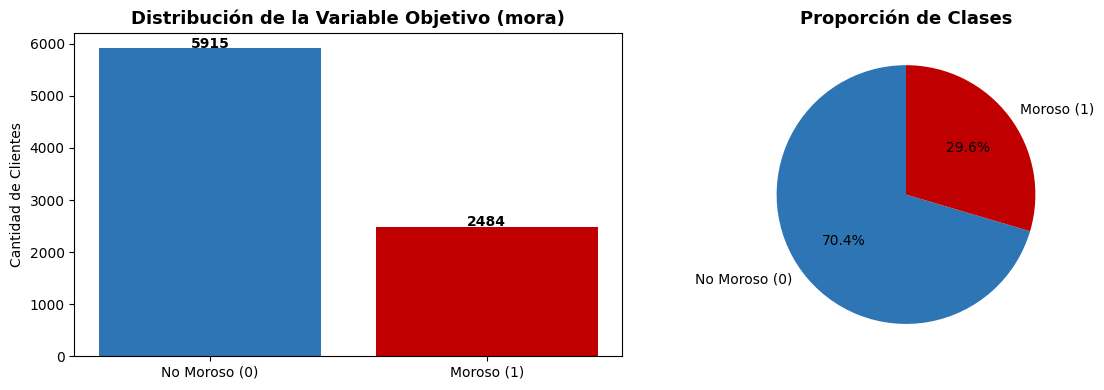


 No Morosos (0): 2484 (29.6%)
 Morosos (1):    5915 (70.4%)


In [ ]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
conteo = df['mora'].value_counts()
axes[0].bar(['No Moroso (0)', 'Moroso (1)'], conteo.values, color=['#2E75B6', '#C00000'])
axes[0].set_title('Distribución de la Variable Objetivo (mora)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(conteo.values, labels=['No Moroso (0)', 'Moroso (1)'],
            autopct='%1.1f%%', colors=['#2E75B6', '#C00000'], startangle=90)
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_mora.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n No Morosos (0): {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)")
print(f" Morosos (1):    {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)")


### 3.4 Análisis de variables numéricas por clase

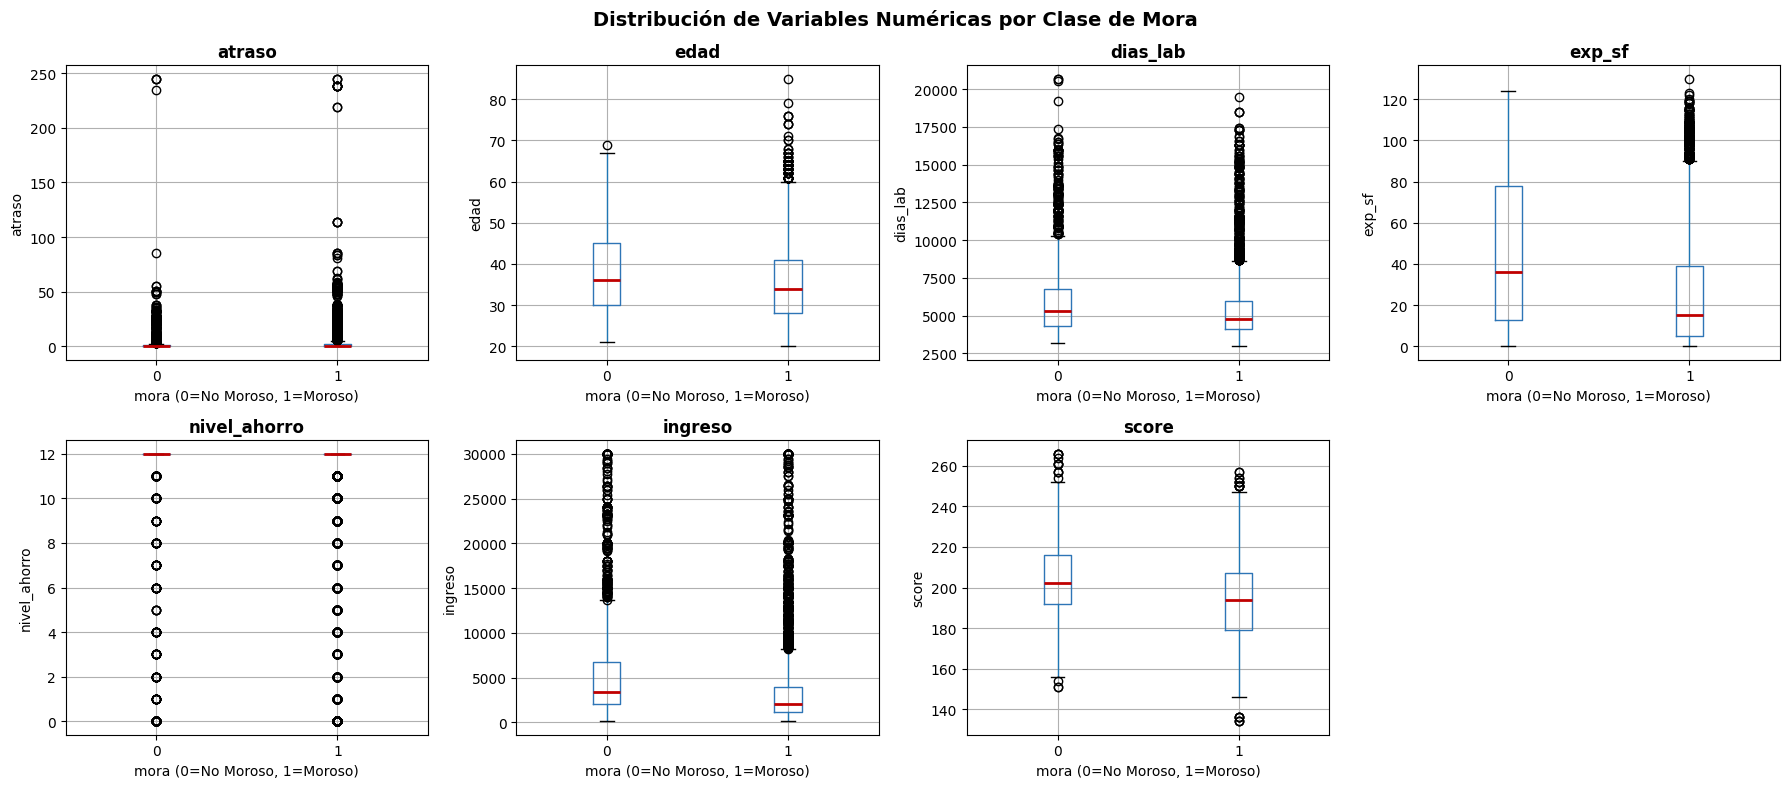

In [ ]:
# Boxplots de variables numéricas por clase de mora
vars_numericas = ['atraso', 'edad', 'dias_lab', 'exp_sf', 'nivel_ahorro', 'ingreso', 'score']
vars_numericas = [v for v in vars_numericas if v in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    df.boxplot(column=var, by='mora', ax=axes[i],
               boxprops=dict(color='#2E75B6'),
               medianprops=dict(color='#C00000', linewidth=2))
    axes[i].set_title(f'{var}', fontweight='bold')
    axes[i].set_xlabel('mora (0=No Moroso, 1=Moroso)')
    axes[i].set_ylabel(var)

# Ocultar eje sobrante
for j in range(len(vars_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas por Clase de Mora', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_variables.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Mapa de correlación

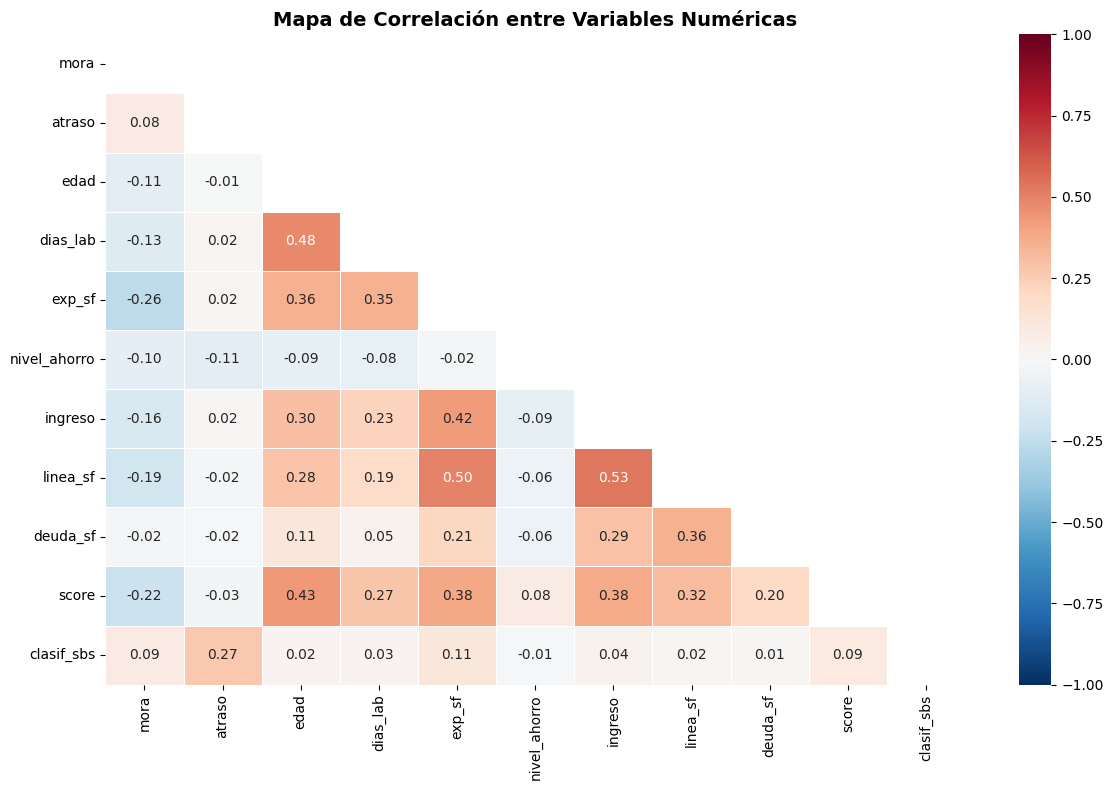

In [ ]:
# Mapa de correlación entre variables numéricas
vars_num_corr = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[vars_num_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mapa_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


##  4. Preprocesamiento y Normalización de Datos

### 4.1 Tratamiento de valores nulos

In [ ]:
# Separar variables numéricas y categóricas
vars_categoricas = df.select_dtypes(include=['object']).columns.tolist()
vars_numericas_todas = df.select_dtypes(include=[np.number]).columns.tolist()
vars_numericas_features = [v for v in vars_numericas_todas if v != 'mora']

print(f"Variables categóricas: {vars_categoricas}")
print(f"Variables numéricas (features): {vars_numericas_features}")

# Imputar nulos: mediana para numéricas, moda para categóricas
for col in vars_numericas_features:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(f"   {col}: imputado con mediana ({mediana:.2f})")

for col in vars_categoricas:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f"   {col}: imputado con moda ({moda})")

print(f"\n Valores nulos restantes: {df.isnull().sum().sum()}")


Variables categóricas: ['vivienda', 'zona', 'nivel_educ']
Variables numéricas (features): ['atraso', 'edad', 'dias_lab', 'exp_sf', 'nivel_ahorro', 'ingreso', 'linea_sf', 'deuda_sf', 'score', 'clasif_sbs']
   exp_sf: imputado con mediana (20.00)
   linea_sf: imputado con mediana (4030.12)
   deuda_sf: imputado con mediana (2258.76)

 Valores nulos restantes: 0


### 4.2 Codificación de variables categóricas (One-Hot Encoding)

In [ ]:
# One-Hot Encoding para variables categóricas
df_encoded = pd.get_dummies(df, columns=vars_categoricas, drop_first=False)

print(f"Dimensiones originales:  {df.shape}")
print(f"Dimensiones tras encoding: {df_encoded.shape}")
print(f"\nColumnas nuevas generadas:")
nuevas_cols = [c for c in df_encoded.columns if c not in df.columns]
for c in nuevas_cols:
    print(f"  - {c}")


Dimensiones originales:  (8399, 14)
Dimensiones tras encoding: (8399, 43)

Columnas nuevas generadas:
  - vivienda_ALQUILADA
  - vivienda_FAMILIAR
  - vivienda_PROPIA
  - zona_Amazonas
  - zona_Ancash
  - zona_Apurimac
  - zona_Arequipa
  - zona_Ayacucho
  - zona_Cajamarca
  - zona_Callao
  - zona_Cuzco
  - zona_Huancavelica
  - zona_Huanuco
  - zona_Ica
  - zona_Junin
  - zona_La Libertad
  - zona_Lambayeque
  - zona_Lima
  - zona_Loreto
  - zona_Madre de Dios
  - zona_Moquegua
  - zona_Pasco
  - zona_Piura
  - zona_Puno
  - zona_San Martin
  - zona_Tacna
  - zona_Tumbes
  - zona_Ucayali
  - nivel_educ_SECUNDARIA
  - nivel_educ_SIN EDUCACION
  - nivel_educ_TECNICA
  - nivel_educ_UNIVERSITARIA


### 4.3 Separación de features y target

In [ ]:
# Separar X (features) e y (target)
X = df_encoded.drop('mora', axis=1)
y = df_encoded['mora']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target):   {y.shape}")
print(f"\nDistribución de clases en y:")
print(y.value_counts())


Shape de X (features): (8399, 42)
Shape de y (target):   (8399,)

Distribución de clases en y:
mora
1    5915
0    2484
Name: count, dtype: int64


### 4.4 División del dataset (70% train / 15% test / 15% validación)

In [ ]:
# División estratificada del dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(" División del Dataset:")
print(f"  Entrenamiento (Train): {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Prueba (Test):         {X_test.shape[0]} registros  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Validación (Val):      {X_val.shape[0]} registros  ({X_val.shape[0]/len(X)*100:.1f}%)")


 División del Dataset:
  Entrenamiento (Train): 5879 registros (70.0%)
  Prueba (Test):         1260 registros  (15.0%)
  Validación (Val):      1260 registros  (15.0%)


### 4.5 Normalización (StandardScaler)

In [ ]:
# Normalización con StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_val_scaled   = scaler.transform(X_val)

print(" Normalización aplicada (media=0, desviación estándar=1)")
print(f"Media de una feature antes: {X_train.iloc[:, 0].mean():.4f}")
print(f"Media de una feature después: {X_train_scaled[:, 0].mean():.4f}")


 Normalización aplicada (media=0, desviación estándar=1)
Media de una feature antes: 4.5970
Media de una feature después: 0.0000


### 4.6 Balanceo de clases con SMOTE (si aplica)

In [ ]:
# Verificar desbalance y aplicar SMOTE si es necesario
ratio = y_train.value_counts()
desbalance = ratio.min() / ratio.max()

print(f"Distribución de clases en Train:")
print(ratio)
print(f"Ratio de desbalance: {desbalance:.2f}")

if desbalance < 0.7:
    print("\n Desbalance detectado — Aplicando SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)
    print(f" Clases balanceadas: {pd.Series(y_train).value_counts().to_dict()}")
else:
    print("\n Dataset balanceado — No se aplica SMOTE")


Distribución de clases en Train:
mora
1    4140
0    1739
Name: count, dtype: int64
Ratio de desbalance: 0.42

 Desbalance detectado — Aplicando SMOTE...
 Clases balanceadas: {0: 4140, 1: 4140}


##  5. Entrenamiento de Modelos

### 5.1 Regresión Lineal (Exploración de relaciones lineales)

In [ ]:
#  Regresión Lineal
# Nota: La regresión lineal no es un clasificador nativo, pero permite
# explorar la relación lineal de las variables con la mora.
# Umbral de clasificación: si predicción >= 0.5 → moroso

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr_raw = lr_model.predict(X_test_scaled)
y_pred_lr = (y_pred_lr_raw >= 0.5).astype(int)

print(" REGRESIÓN LINEAL (adaptada a clasificación)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precisión: {precision_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_lr, zero_division=0):.4f}")

# Coeficientes más importantes
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lr_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\nTop 10 variables más influyentes (por coeficiente):")
print(coef_df.head(10).to_string(index=False))


 REGRESIÓN LINEAL (adaptada a clasificación)
  Accuracy:  0.6579
  Precisión: 0.8260
  Recall:    0.6520
  F1-Score:  0.7288

Top 10 variables más influyentes (por coeficiente):
      Feature  Coeficiente
        score    -0.084459
       exp_sf    -0.070485
   clasif_sbs     0.063765
 nivel_ahorro    -0.063622
     deuda_sf     0.036997
     dias_lab    -0.029841
     linea_sf    -0.026907
  zona_Loreto     0.024592
zona_Arequipa    -0.024473
       atraso     0.023949


### 5.2 Regresión Logística (Modelo Base / Baseline)

In [ ]:
#  Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log  = log_reg.predict_proba(X_test_scaled)[:, 1]

print(" REGRESIÓN LOGÍSTICA (Baseline)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
print(f"  Precisión: {precision_score(y_test, y_pred_log, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_log, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_log, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_log):.4f}")


 REGRESIÓN LOGÍSTICA (Baseline)
  Accuracy:  0.6563
  Precisión: 0.8245
  Recall:    0.6509
  F1-Score:  0.7275
  AUC-ROC:   0.7242


### 5.3 Árbol de Decisión

 ÁRBOL DE DECISIÓN
  Accuracy:  0.6270
  Precisión: 0.8542
  Recall:    0.5676
  F1-Score:  0.6820
  AUC-ROC:   0.7053


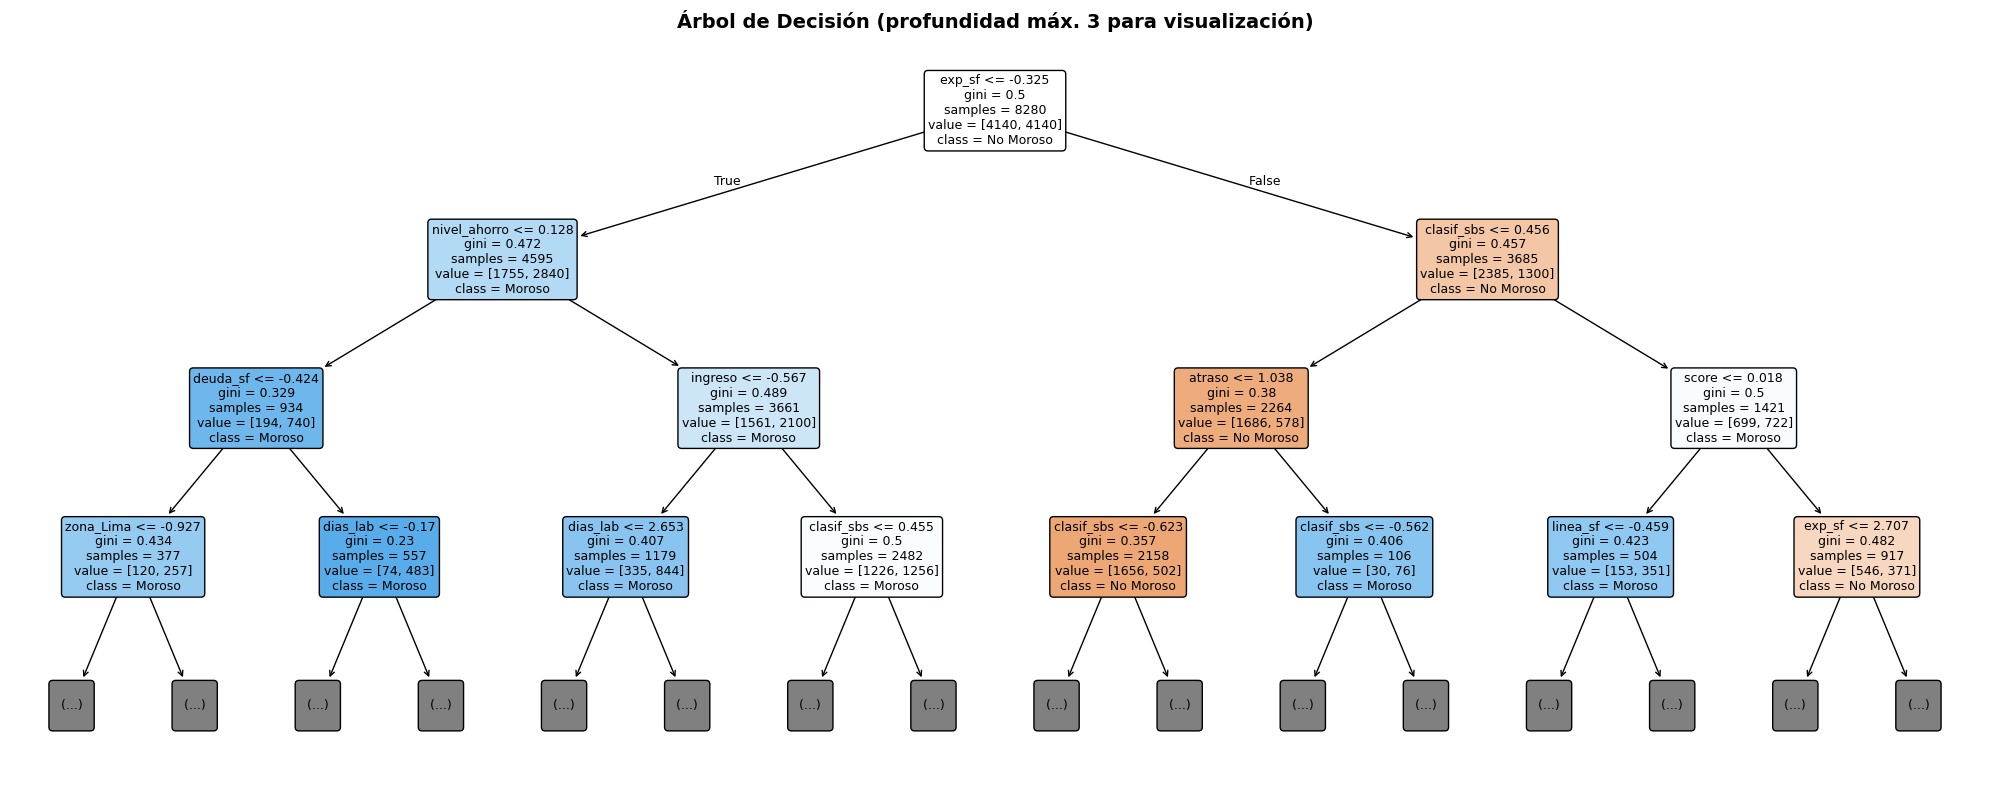

In [ ]:
#  Árbol de Decisión
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt  = dt_model.predict_proba(X_test_scaled)[:, 1]

print(" ÁRBOL DE DECISIÓN")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precisión: {precision_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_dt):.4f}")

# Visualizar el árbol
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Moroso', 'Moroso'],
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title('Árbol de Decisión (profundidad máx. 3 para visualización)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Random Forest

In [ ]:
#  Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]

print(" RANDOM FOREST")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precisión: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")


 RANDOM FOREST
  Accuracy:  0.7683
  Precisión: 0.8661
  Recall:    0.7939
  F1-Score:  0.8284
  AUC-ROC:   0.8329


##  6. Validación Cruzada (k-Fold, k=5)

In [ ]:
# Validación cruzada estratificada k=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Regresión Logística': log_reg,
    'Árbol de Decisión':   dt_model,
    'Random Forest':       rf_model,
}

print(" RESULTADOS DE VALIDACIÓN CRUZADA (k=5):")
print("=" * 60)

resultados_cv = {}
for nombre, modelo in modelos_cv.items():
    scores_acc = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    scores_f1  = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='f1')
    scores_auc = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

    resultados_cv[nombre] = {
        'Accuracy':  scores_acc.mean(),
        'F1-Score':  scores_f1.mean(),
        'AUC-ROC':   scores_auc.mean(),
    }

    print(f"\n{nombre}:")
    print(f"  Accuracy (CV):  {scores_acc.mean():.4f} ± {scores_acc.std():.4f}")
    print(f"  F1-Score (CV):  {scores_f1.mean():.4f} ± {scores_f1.std():.4f}")
    print(f"  AUC-ROC (CV):   {scores_auc.mean():.4f} ± {scores_auc.std():.4f}")


 RESULTADOS DE VALIDACIÓN CRUZADA (k=5):

Regresión Logística:
  Accuracy (CV):  0.6643 ± 0.0095
  F1-Score (CV):  0.6677 ± 0.0112
  AUC-ROC (CV):   0.7220 ± 0.0089

Árbol de Decisión:
  Accuracy (CV):  0.6851 ± 0.0083
  F1-Score (CV):  0.6664 ± 0.0282
  AUC-ROC (CV):   0.7573 ± 0.0110

Random Forest:
  Accuracy (CV):  0.8041 ± 0.0106
  F1-Score (CV):  0.8029 ± 0.0119
  AUC-ROC (CV):   0.8837 ± 0.0073


##  7. Evaluación Comparativa de Modelos

In [ ]:
# Tabla comparativa de todos los modelos
resultados = {
    'Modelo': ['Regresión Lineal*', 'Regresión Logística', 'Árbol de Decisión', 'Random Forest'],
    'Accuracy':  [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ],
    'Precisión': [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_lr_raw),
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
    ],
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.round(4)
print("* Regresión Lineal adaptada a clasificación con umbral 0.5")
print()
print(df_resultados.to_string())


* Regresión Lineal adaptada a clasificación con umbral 0.5

                     Accuracy  Precisión  Recall  F1-Score  AUC-ROC
Modelo                                                             
Regresión Lineal*      0.6579     0.8260  0.6520    0.7288   0.7232
Regresión Logística    0.6563     0.8245  0.6509    0.7275   0.7242
Árbol de Decisión      0.6270     0.8542  0.5676    0.6820   0.7053
Random Forest          0.7683     0.8661  0.7939    0.8284   0.8329


### 7.1 Matrices de Confusión

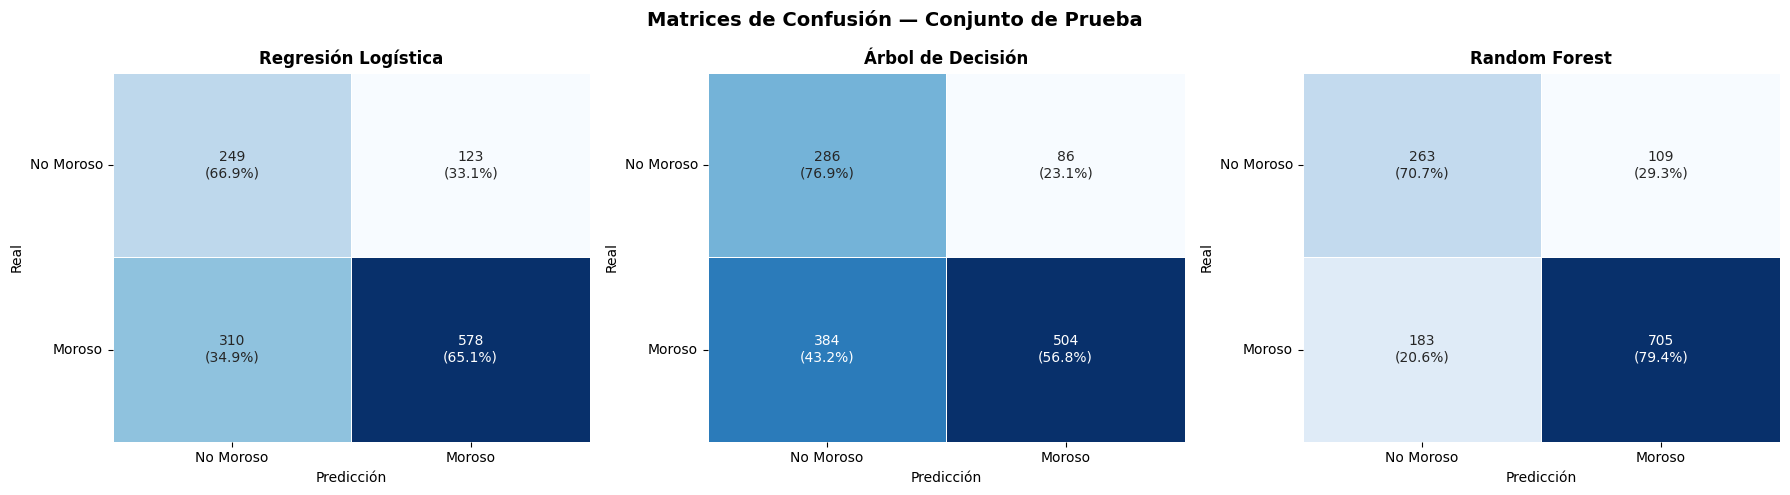

In [ ]:
# Matrices de confusión de los 3 modelos de clasificación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_info = [
    ('Regresión Logística', y_pred_log),
    ('Árbol de Decisión',   y_pred_dt),
    ('Random Forest',       y_pred_rf),
]

for ax, (nombre, y_pred) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels = [[f"{v1}\n({v2:.1%})" for v1, v2 in zip(row1, row2)]
              for row1, row2 in zip(cm, cm_pct)]
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                cbar=False, linewidths=0.5)
    ax.set_title(nombre, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['No Moroso', 'Moroso'])
    ax.set_yticklabels(['No Moroso', 'Moroso'], rotation=0)

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Curvas ROC

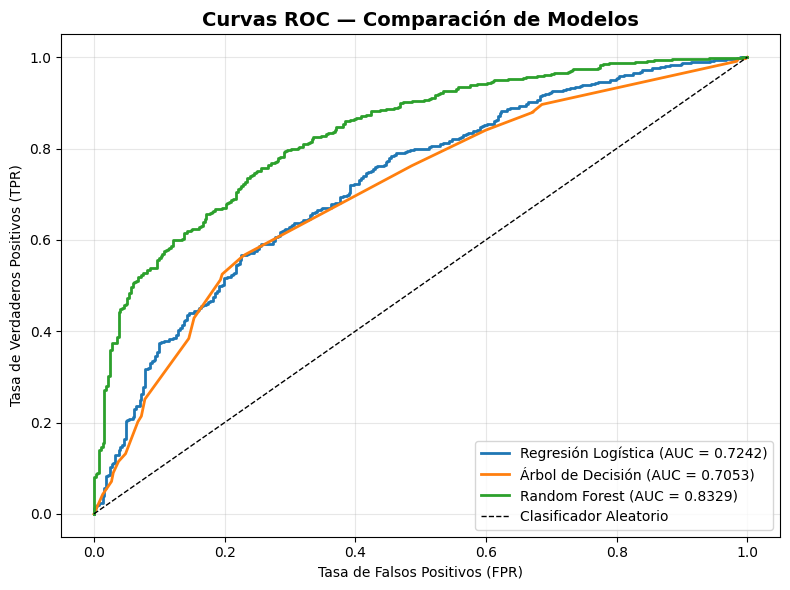

In [ ]:
# Curvas ROC comparativas
plt.figure(figsize=(8, 6))

for nombre, y_prob in [('Regresión Logística', y_prob_log),
                        ('Árbol de Decisión',   y_prob_dt),
                        ('Random Forest',       y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Importancia de Variables (Random Forest)

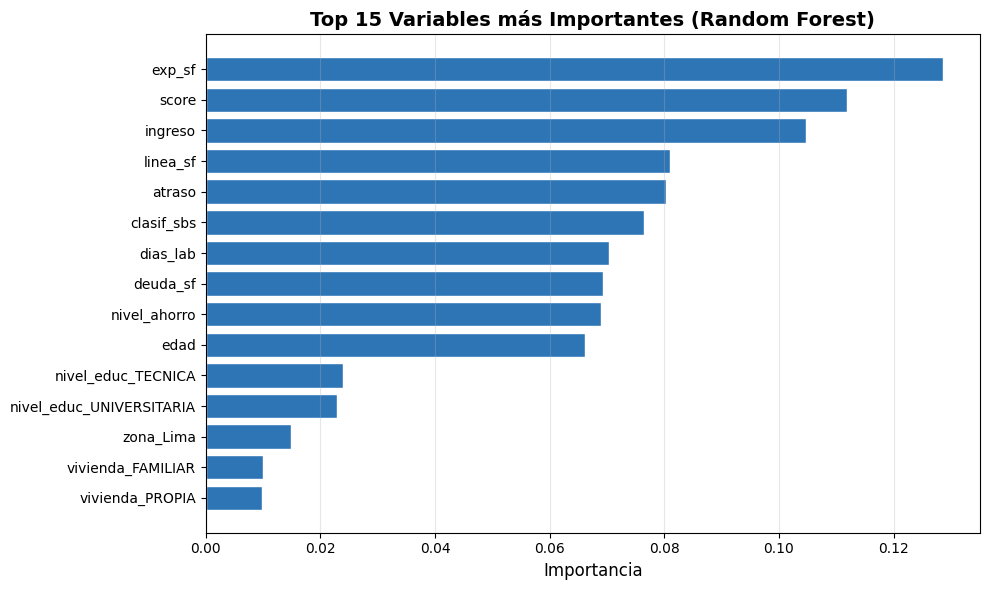


Top 10 variables más influyentes en la predicción de mora:
    Variable  Importancia
      exp_sf     0.128643
       score     0.111845
     ingreso     0.104770
    linea_sf     0.081020
      atraso     0.080340
  clasif_sbs     0.076366
    dias_lab     0.070294
    deuda_sf     0.069268
nivel_ahorro     0.068926
        edad     0.066113


In [ ]:
# Importancia de variables según Random Forest
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(importancias['Variable'][::-1], importancias['Importancia'][::-1],
                color='#2E75B6', edgecolor='white')
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 15 Variables más Importantes (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 variables más influyentes en la predicción de mora:")
print(importancias.head(10).to_string(index=False))


##  8. Selección y Exportación del Modelo Final

In [ ]:
# Seleccionar el mejor modelo según AUC-ROC
mejor_modelo_nombre = df_resultados['AUC-ROC'].idxmax()
print(f" Mejor modelo según AUC-ROC: {mejor_modelo_nombre}")
print(f"   AUC-ROC: {df_resultados.loc[mejor_modelo_nombre, 'AUC-ROC']:.4f}")
print(f"   F1-Score: {df_resultados.loc[mejor_modelo_nombre, 'F1-Score']:.4f}")

# Seleccionar el modelo ganador
modelos_dict = {
    'Regresión Logística': log_reg,
    'Árbol de Decisión':   dt_model,
    'Random Forest':       rf_model,
}

mejor_modelo = modelos_dict.get(mejor_modelo_nombre, rf_model)

# Reporte final del modelo ganador
print("\n" + "=" * 50)
print(f"REPORTE DE CLASIFICACIÓN — {mejor_modelo_nombre}")
print("=" * 50)
y_pred_final = mejor_modelo.predict(X_test_scaled)
print(classification_report(y_test, y_pred_final, target_names=['No Moroso', 'Moroso']))


 Mejor modelo según AUC-ROC: Random Forest
   AUC-ROC: 0.8329
   F1-Score: 0.8284

REPORTE DE CLASIFICACIÓN — Random Forest
              precision    recall  f1-score   support

   No Moroso       0.59      0.71      0.64       372
      Moroso       0.87      0.79      0.83       888

    accuracy                           0.77      1260
   macro avg       0.73      0.75      0.74      1260
weighted avg       0.78      0.77      0.77      1260



In [ ]:
# Exportar el modelo y el scaler para el deploy
joblib.dump(mejor_modelo, 'modelo_crediticio.pkl')
joblib.dump(scaler, 'scaler_crediticio.pkl')
joblib.dump(list(X.columns), 'features_crediticio.pkl')

print(" Modelo guardado como: modelo_crediticio.pkl")
print(" Scaler guardado como: scaler_crediticio.pkl")
print(" Features guardadas como: features_crediticio.pkl")

# Descargar archivos desde Colab
from google.colab import files
files.download('modelo_crediticio.pkl')
files.download('scaler_crediticio.pkl')
files.download('features_crediticio.pkl')


 Modelo guardado como: modelo_crediticio.pkl
 Scaler guardado como: scaler_crediticio.pkl
 Features guardadas como: features_crediticio.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  9. Prueba de Predicción con Nuevo Cliente

In [ ]:
# Función para predecir la mora de un nuevo cliente
def predecir_cliente(datos_cliente: dict) -> dict:
    """
    Predice si un cliente será moroso o no.

    Parámetros:
    - datos_cliente: dict con los valores del cliente

    Retorna:
    - dict con predicción y probabilidad
    """
    # Crear DataFrame con los datos del cliente
    df_cliente = pd.DataFrame([datos_cliente])

    # Aplicar One-Hot Encoding con las mismas columnas del entrenamiento
    df_cliente_enc = pd.get_dummies(df_cliente)

    # Alinear columnas (agregar las que falten con valor 0)
    for col in X.columns:
        if col not in df_cliente_enc.columns:
            df_cliente_enc[col] = 0
    df_cliente_enc = df_cliente_enc[X.columns]

    # Normalizar
    df_cliente_scaled = scaler.transform(df_cliente_enc)

    # Predecir
    prediccion = mejor_modelo.predict(df_cliente_scaled)[0]
    probabilidad = mejor_modelo.predict_proba(df_cliente_scaled)[0][1]

    resultado = {
        'prediccion': 'MOROSO ' if prediccion == 1 else 'NO MOROSO ',
        'probabilidad_mora': f"{probabilidad*100:.2f}%",
        'riesgo': 'ALTO' if probabilidad > 0.7 else ('MEDIO' if probabilidad > 0.4 else 'BAJO')
    }
    return resultado

#  EJEMPLO DE PRUEBA
cliente_ejemplo = {
    'atraso': 5,
    'edad': 32,
    'dias_lab': 4500,
    'exp_sf': 24,
    'nivel_ahorro': 8,
    'ingreso': 2500,
    'linea_sf': 5000,
    'deuda_sf': 1200,
    'score': 180,
    'clasif_sbs': 1,
    'vivienda': 'PROPIA',
    'zona': 'La Libertad',
    'nivel_educ': 'UNIVERSITARIA',
}

resultado = predecir_cliente(cliente_ejemplo)

print("=" * 50)
print(" PERFIL DEL CLIENTE:")
for k, v in cliente_ejemplo.items():
    print(f"  {k}: {v}")
print()
print(" RESULTADO DE LA PREDICCIÓN:")
print(f"  Predicción:          {resultado['prediccion']}")
print(f"  Probabilidad de mora: {resultado['probabilidad_mora']}")
print(f"  Nivel de riesgo:     {resultado['riesgo']}")
print("=" * 50)


 PERFIL DEL CLIENTE:
  atraso: 5
  edad: 32
  dias_lab: 4500
  exp_sf: 24
  nivel_ahorro: 8
  ingreso: 2500
  linea_sf: 5000
  deuda_sf: 1200
  score: 180
  clasif_sbs: 1
  vivienda: PROPIA
  zona: La Libertad
  nivel_educ: UNIVERSITARIA

 RESULTADO DE LA PREDICCIÓN:
  Predicción:          MOROSO 
  Probabilidad de mora: 66.57%
  Nivel de riesgo:     MEDIO


##  10. Conclusiones

Con este notebook hemos completado el pipeline completo del proyecto:

1. **Carga y EDA**: Exploración del dataset BankDefaultAnalysis con 14 variables crediticias del sistema financiero peruano.
2. **Preprocesamiento**: Tratamiento de nulos, One-Hot Encoding, normalización con StandardScaler y balanceo con SMOTE.
3. **Modelos entrenados**:
   - Regresión Lineal (análisis de relaciones lineales)
   - Regresión Logística (baseline)
   - Árbol de Decisión
   - Random Forest
4. **Evaluación**: Comparación mediante Accuracy, Precisión, Recall, F1-Score y AUC-ROC.
5. **Validación cruzada**: k-Fold (k=5) para garantizar generalización.
6. **Exportación**: Modelo guardado en `.pkl` listo para el deploy en Streamlit.

